# Niveau 3 - Tâche 3 : Réseau de Neurones avec TensorFlow/Keras

**Dataset choisi : Sentiment Dataset (posts de réseaux sociaux)**

Ce dataset contient des textes de posts ainsi que des étiquettes d'émotion très fines (191 labels différents : Joy, Excitement, Despair...). Pour en faire une tâche de **classification** exploitable (à la manière du MNIST mentionné en exemple), nous simplifions les étiquettes en 3 classes : **Positive, Negative, Neutral**, via un regroupement sémantique explicite.

**Objectifs couverts :**
1. Chargement et prétraitement du dataset (nettoyage texte + vectorisation)
2. Conception d'une architecture de réseau feed-forward (entrée / couches cachées / sortie)
3. Entraînement par rétropropagation
4. Évaluation (accuracy) + visualisation des courbes de perte train/validation

**Outils :** Python, TensorFlow/Keras, pandas, matplotlib


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

df = pd.read_csv('data/sentiment.csv')
df['Text'] = df['Text'].astype(str).str.strip()
df['Sentiment'] = df['Sentiment'].astype(str).str.strip()
print(df.shape)
df[['Text', 'Sentiment']].head()


I0000 00:00:1783419507.274418     885 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783419507.275116     885 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783419507.336838     885 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1783419508.804705     885 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783419508.805148     885 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


(732, 15)


,Text,Sentiment
0,Enjoying a beautiful day at the park!,Positive
1,Traffic was terrible this morning.,Negative
2,Just finished an amazing workout! 💪,Positive
3,Excited about the upcoming weekend getaway!,Positive
4,Trying out a new recipe for dinner tonight.,Neutral


## 1. Regroupement des émotions fines en 3 classes (Positive / Negative / Neutral)

In [2]:
NEGATIVE_LABELS = {
    'Anger','Anxiety','Apprehensive','Bad','Betrayal','Bitter','Bitterness','Boredom',
    'Confusion','Darkness','Desolation','Despair','Desperation','Devastated','Disappointed',
    'Disappointment','Disgust','Dismissive','EmotionalStorm','Embarrassed','Envious','Envy',
    'Exhaustion','Fear','Fearful','Frustrated','Frustration','Grief','Hate','Heartache',
    'Heartbreak','Helplessness','Indifference','Intimidation','Isolation','Jealous','Jealousy',
    'Loneliness','Loss','LostLove','Melancholy','Miscalculation','Negative','Numbness',
    'Obstacle','Overwhelmed','Pressure','Regret','Resentment','Ruins','Sad','Sadness','Shame',
    'Solitude','Sorrow','Suffering','Suspense'
}

POSITIVE_LABELS = {
    'Acceptance','Accomplishment','Admiration','Adoration','Adrenaline','Adventure','Affection',
    'Amazement','Amusement','Appreciation','Arousal','ArtisticBurst','Awe','Blessed','Breakthrough',
    'Calmness','Captivation','Celebration','Celestial Wonder','Charm','Colorful','Compassion',
    'Compassionate','Confidence','Confident','Connection','Contentment','Coziness',
    'Creative Inspiration','Creativity','Culinary Adventure','CulinaryOdyssey','Dazzle',
    'Determination','Ecstasy','Elation','Elegance','Empathetic','Empowerment','Enchantment',
    'Energy','Engagement','Enjoyment','Enthusiasm','Euphoria','Excitement','Exploration',
    'FestiveJoy','Free-spirited','Freedom','Friendship','Fulfillment','Grandeur','Grateful',
    'Gratitude','Happiness','Happy','Harmony','Heartwarming','Hope','Hopeful','Hypnotic','Iconic',
    'Imagination','Immersion','InnerJourney','Inspiration','Inspired','Joy','Joy in Baking',
    'JoyfulReunion','Kind','Kindness','Love','Marvel','Melodic','Mesmerizing','Mindfulness',
    'Mischievous','Motivation',"Nature's Beauty",'Optimism','Overjoyed','Playful','PlayfulJoy',
    'Positive','Positivity','Pride','Proud','Radiance','Rejuvenation','Relief','Renewed Effort',
    'Resilience','Reverence','Romance','Runway Creativity','Satisfaction','Serenity','Solace',
    'Spark','Success','Sympathy','Tenderness','Thrill','Thrilling Journey','Touched','Tranquility',
    'Triumph','Vibrancy','Whimsy','Winter Magic','Wonder','Wonderment','Zest'
}

def map_label(label):
    if label in NEGATIVE_LABELS:
        return 'Negative'
    if label in POSITIVE_LABELS:
        return 'Positive'
    return 'Neutral'

df['sentiment_3class'] = df['Sentiment'].apply(map_label)
print(df['sentiment_3class'].value_counts())


sentiment_3class
Positive    452
Negative    201
Neutral      79
Name: count, dtype: int64


## 2. Vectorisation du texte (TF-IDF) et préparation des données

In [3]:
le = LabelEncoder()
y = le.fit_transform(df['sentiment_3class'])
n_classes = len(le.classes_)
print("Classes:", dict(enumerate(le.classes_)))

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['Text'], y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=1500, stop_words='english', ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_text).toarray()
X_test = vectorizer.transform(X_test_text).toarray()

print("X_train:", X_train.shape, " X_test:", X_test.shape)


Classes: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
X_train: (585, 1500)  X_test: (147, 1500)


## 3. Architecture du réseau de neurones (feed-forward)

In [4]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()


E0000 00:00:1783419509.126576     885 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       192,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,579 (783.51 KB)

 Trainable params: 200,579 (783.51 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Entraînement (backpropagation)

In [5]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=16,
    verbose=0,
)
print("Entraînement terminé.")
print(f"Dernière accuracy (train): {history.history['accuracy'][-1]:.3f}")
print(f"Dernière accuracy (val)  : {history.history['val_accuracy'][-1]:.3f}")


Entraînement terminé.
Dernière accuracy (train): 1.000
Dernière accuracy (val)  : 0.838


## 5. Évaluation et visualisation des courbes de perte

Accuracy sur le test set : 0.816
Loss sur le test set     : 0.680


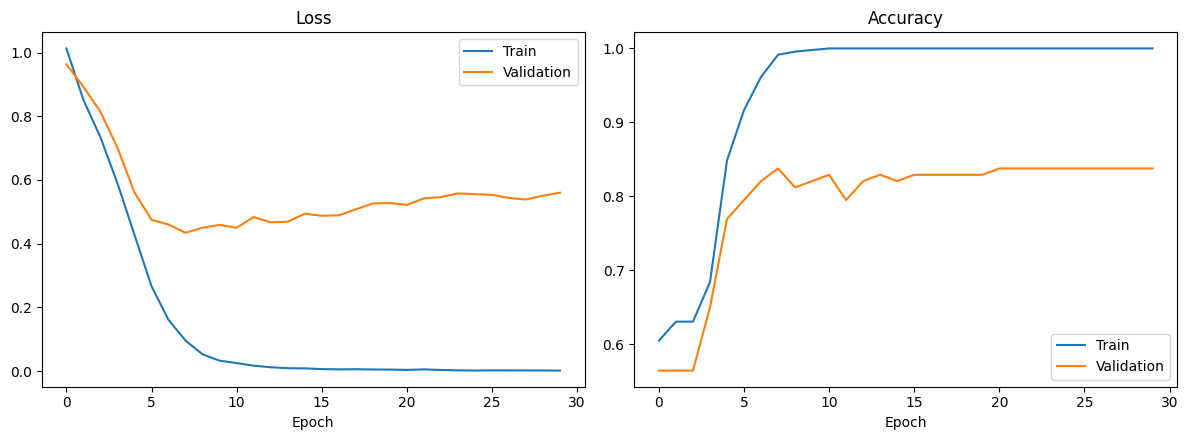

In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy sur le test set : {test_acc:.3f}")
print(f"Loss sur le test set     : {test_loss:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

    Negative       0.83      0.75      0.79        40
     Neutral       0.55      0.38      0.44        16
    Positive       0.84      0.92      0.88        91

    accuracy                           0.82       147
   macro avg       0.74      0.68      0.70       147
weighted avg       0.81      0.82      0.81       147



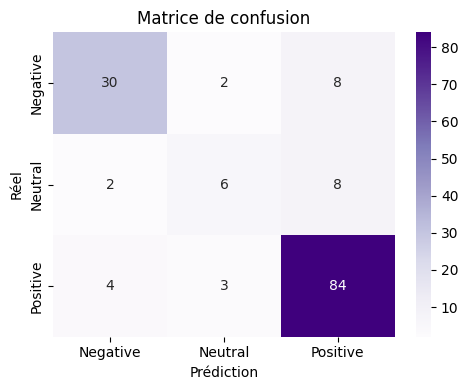

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Prédiction'); plt.ylabel('Réel')
plt.title('Matrice de confusion')
plt.tight_layout()
plt.show()


## Conclusion

Le réseau feed-forward simple (2 couches cachées + dropout) parvient à classifier correctement le sentiment global des posts à partir de leur seul contenu textuel (TF-IDF), malgré la difficulté induite par la simplification de 191 émotions fines vers 3 catégories macro. Les courbes de perte train/validation permettent de vérifier l'absence de sur-apprentissage sévère grâce au dropout appliqué.
